In [1]:
# Import packages 
import pandas as pd
import seaborn as sns


In [ ]:
# load datased from seaborn package about penguins
penguins = sns.load_dataset('penguins')
penguins.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [8]:
penguins_sub = penguins[penguins['species'] != 'Chinstrap']
#drop NA values
penguins_sub_final = penguins_sub.dropna()
penguins_sub_final.reset_index(drop=True, inplace=True)

# EDA

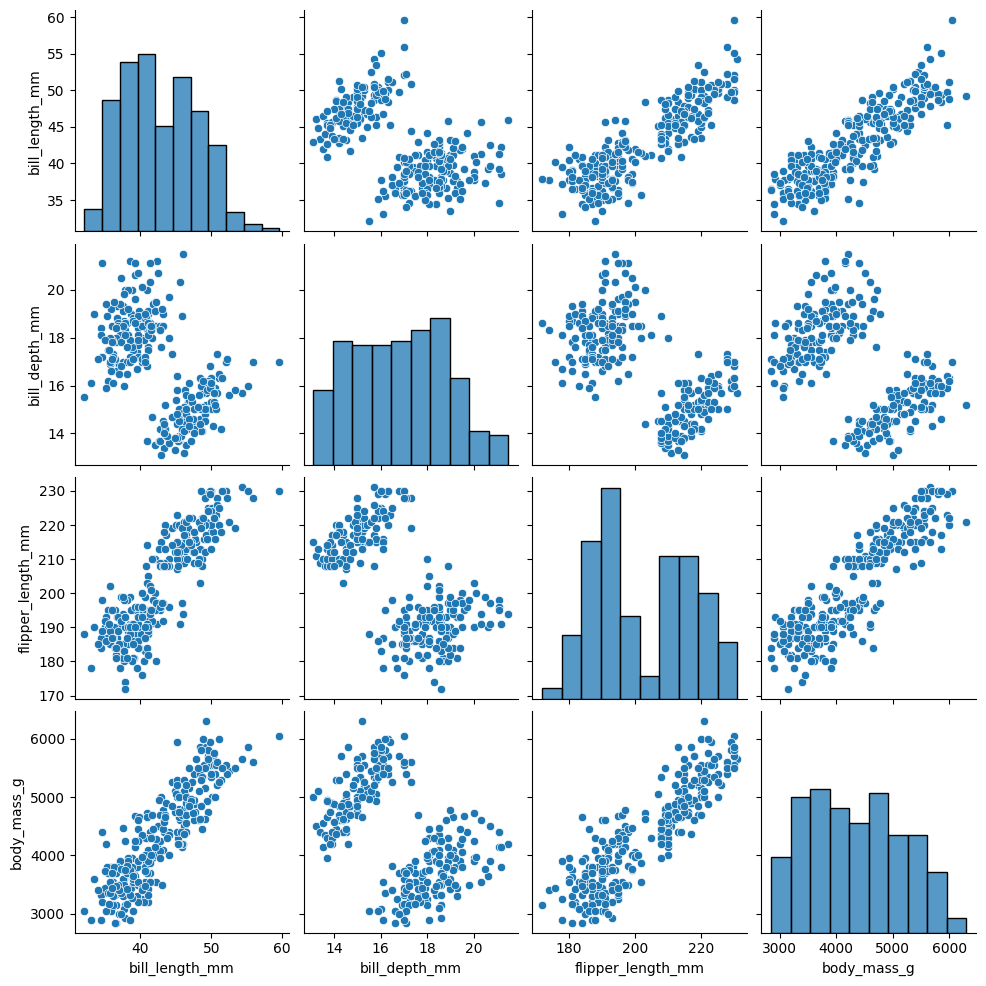

In [9]:
sns.pairplot(penguins_sub_final)

In [ ]:
# create dataframe only for dependent and independent variables
ols_data = penguins_sub_final[['bill_length_mm', 'body_mass_g']]
ols_data.head(5)

,bill_length_mm,body_mass_g
0,39.1,3750.0
1,39.5,3800.0
2,40.3,3250.0
3,36.7,3450.0
4,39.3,3650.0


In [12]:
#regression formula
ols_formula = 'bill_length_mm ~ body_mass_g'

In [ ]:
#import statsmodels package
from statsmodels.formula.api import ols # Importing least squares model
# build model 

model = ols(formula = ols_formula, data = penguins_sub_final)
# Fit OLS model to data 
model = model.fit()
# Print model summary
model.summary()

# R-squared = 0.77. Meaning that 77% variance in bill_length_mm is explained by body_mass_g
# P-value is smaller than 0.05. This means that the relationship between bill_length_mm and body_mass_g is statistically significant
# Intercept is 19.18 
# Slope is 0.0054 meaning that for every 1gg increase in body_mass_g, bill_length_mm will increase by 0.0054mm

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         bill_length_mm   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     874.3
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           1.33e-85
Time:                        18:09:04   Log-Likelihood:                -619.15
No. Observations:                 265   AIC:                             1242.
Df Residuals:                     263   BIC:                             1249.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      19.1818      0.812     23.626      0.000      17.583      20.780
body_mass_g     0.0054      0.000     29.569      0.000       0.005       0.006
==============================================================================
Omnibus:                        1.003   Durbin-Watson:                   1.886
Prob(Omnibus):                  0.606   Jarque-Bera (JB):                0.768
Skew:                          -0.117   Prob(JB):                        0.681
Kurtosis:                       3.121   Cond. No.                     2.32e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.32e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='None', ylabel='None'>

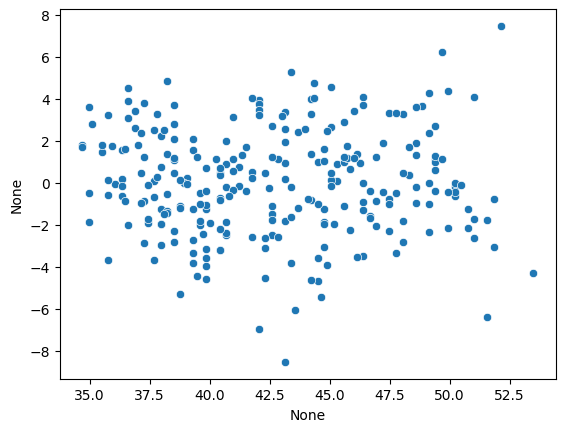

In [ ]:
X = penguins_sub_final['body_mass_g']

# predict values of y based on new values of x
y_pred = model.predict(X)

# residuals
residuals =model.resid

<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

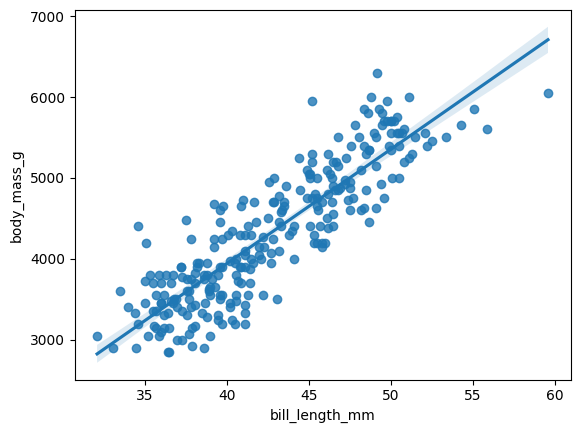

In [23]:
sns.regplot(x='bill_length_mm', y='body_mass_g', data=penguins_sub_final)

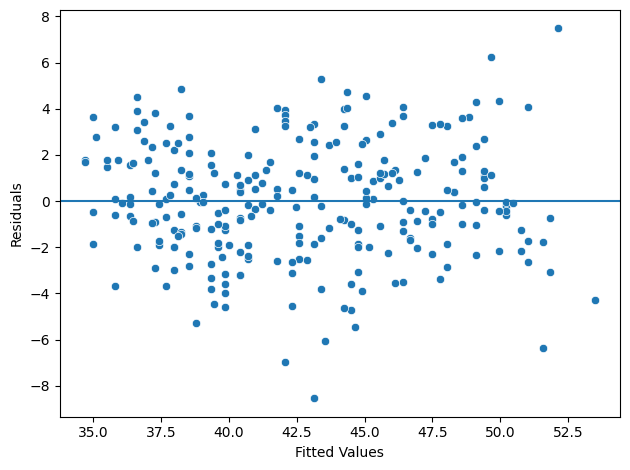

In [45]:
import matplotlib.pyplot as plt

fig = sns.scatterplot(y=residuals, x=y_pred)
fig.axhline(y=0)
fig.set_xlabel('Fitted Values')
fig.set_ylabel('Residuals')
plt.tight_layout()
plt.show()

# Residuals seem randomly spaced - homescedasticity assumed 

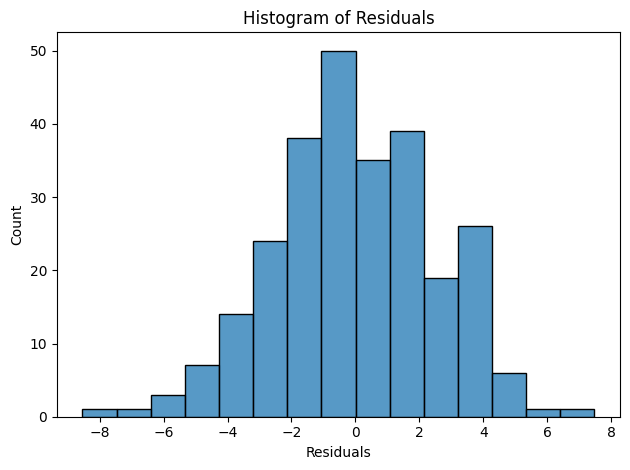

In [ ]:
fig = sns.histplot(residuals)
fig.set_xlabel('Residuals')
fig.set_title("Histogram of Residuals")
plt.tight_layout()
plt.show()

# Residuals are normally distributed

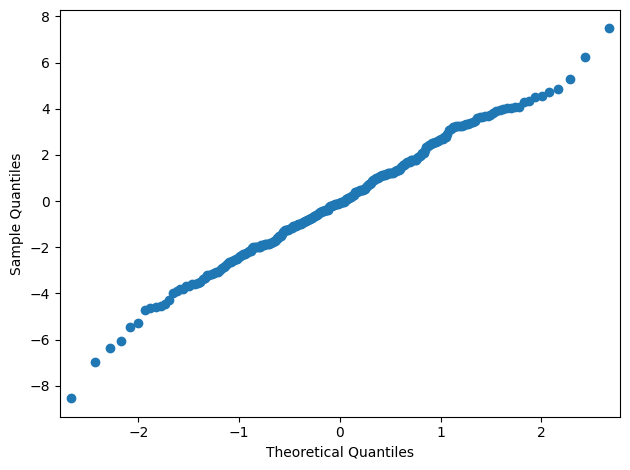

In [47]:
import statsmodels.api as sm

fig = sm.qqplot(residuals)


plt.tight_layout()
plt.show()

# Residuals are normally distributed